# Plotnine and summary operations

## Introduction

In this exploration of __plotnine__, I look at some of the summary __stat__ functions that are available.

------------------------

## Implementation

### Imports

- warnings can be used to supress unwanted warning message from __plotnine__
- numpy does numerical calulations (here, mostly random number generation)
- plotnine, the star of the show
- scipy, scientific Python

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotnine as p9
from scipy import stats

__watermark__ provides reproducability information

In [2]:
%load_ext watermark

-------------------------
## stat_sum

__stat_sum__ appears to be designed for the case where we have multiple data points, but many overlap.  For example, suppose we collect bird species sightings over a period of time, at a number of different sites; or we record (for a number of patients) the side-effects observed for different drug dosages.

I am going to abstract this as multiple rows of X, Y coordinates, with the interest being is visualizing how many times a particular X,Y combination appears.

Generate example data:

In [3]:
size = 100

In [4]:
x = np.random.randint(low=0, high=11, size=100)
y = np.random.randint(low=0, high=11, size=100)


df = pd.DataFrame({"x": x, "y": y})

-------------------------
## __geom_point__: nice try, but ...

The initial (hopeful) way to visualize this is to use __geom_point__.

We: 

- create an empty plot, specifying the source of data
- create a layer with points
- set the y axis to have tick marks at the integer values 0-10
- set the x axis to have tick marks at the integer values 0-10
- set the theme to Black & White

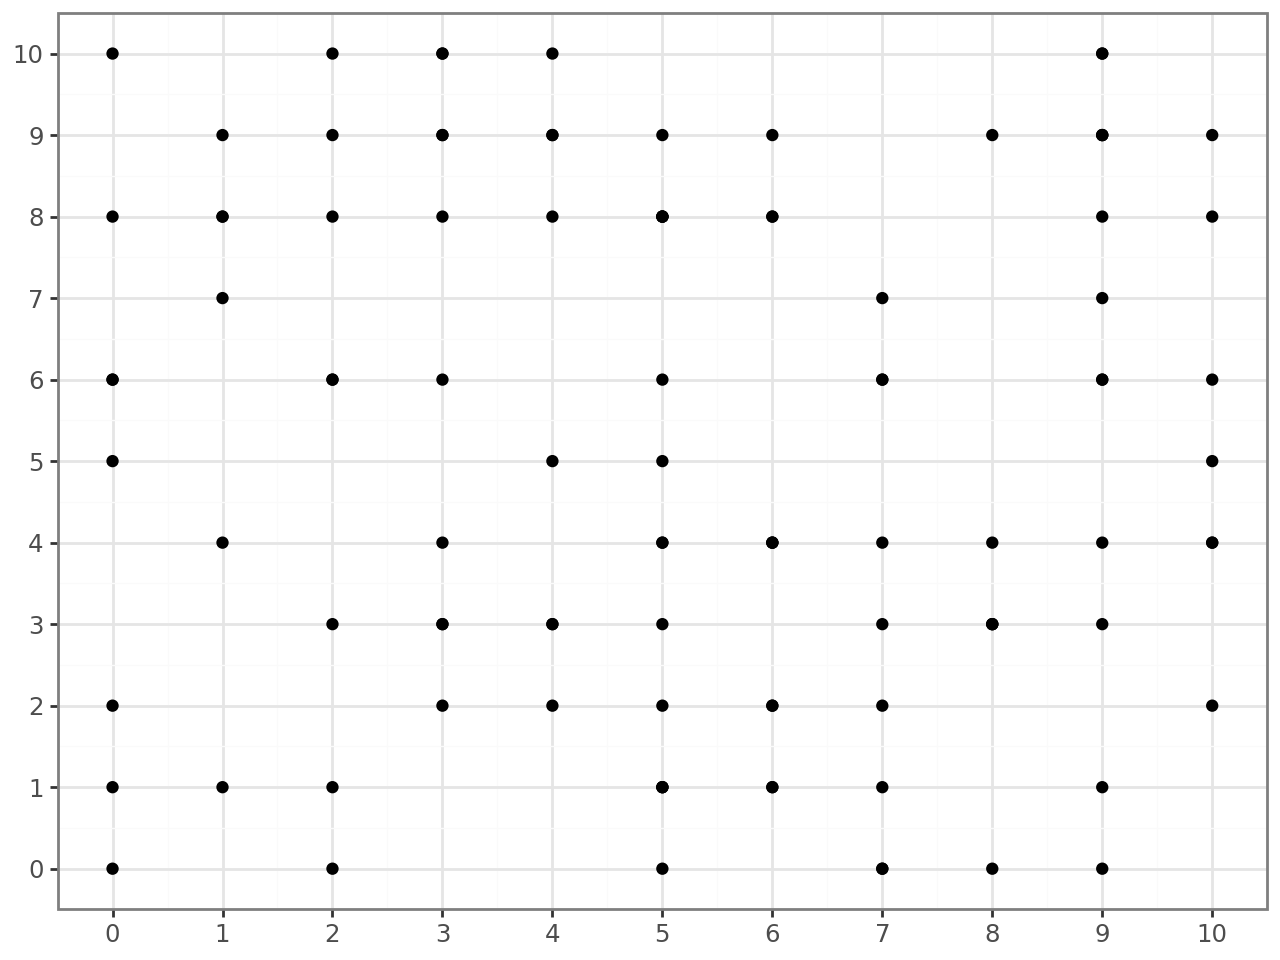

In [5]:
plot = (
    p9.ggplot(data=None)
    + p9.geom_point(
        mapping=p9.aes(
            x=x,
            y=y,
        ),
    )
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)

plot

As can be seen above, this fails, in the sense that at each X,Y pair the multiple points overlap.  There is no way to get a sense of how many X,Y observations we have.

---------------------

## __geom_jitter__ to the rescue

This is exactly the situation that __geom_jitter__ was invented to handle

We:

- create an empty plot, specifying the source of data
- plot the points, but each point is randomly shifted up-down, and left-right
- plot the true location of each point as a "+", to act as a centre of the jittered distribution
- set the y axis to have tick marks at the integer values 0-10
- set the x axis to have tick marks at the integer values 0-10
- set the theme to Black & White

In order to visually group the jittered points, I have color-coded each group with a different color.  I supress the default legend, as the color-coding has no experimental meaning.

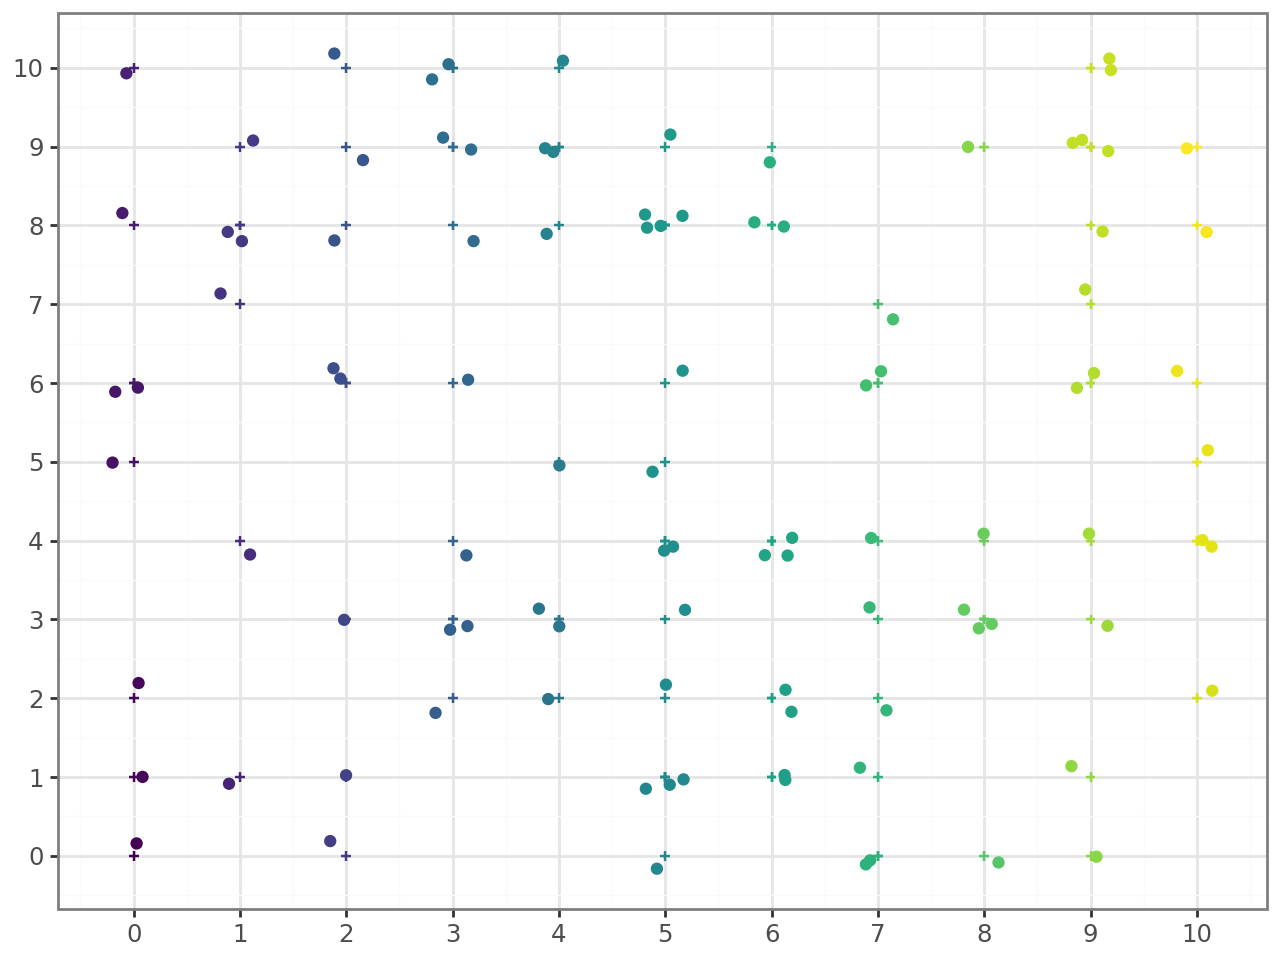

In [6]:
jitter = 0.2

plot = (
    p9.ggplot(data=None)
    + p9.geom_jitter(
        mapping=p9.aes(x=x, y=y, color="x*10+y"),
        width=jitter,
        height=jitter,
        show_legend=False,
    )
    + p9.geom_point(
        mapping=p9.aes(x=x, y=y, color="x*10+y"),
        shape="+",
        show_legend=False,
    )
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)

plot

-------------------------

## __stat_sum__: a tidier visual effect

I don't really like the jitter effect above, largely because I believe the random jittering creates groups of different size for the same data-point count, making it hard to compare different X,Y clusters.  On to __stat_sum__!

We  call the statistical process __stat_sum__ and by default it will call __geom__point__, setting the size of each point according to the count of items at that point:

Steps are: 

- create an empty plot, specifying the source of data
- invoke a summing statistical process, operating on our X,Y pairs
- set the y axis to have tick marks at the integer values 0-10
- set the x axis to have tick marks at the integer values 0-10
- set the theme to Black & White

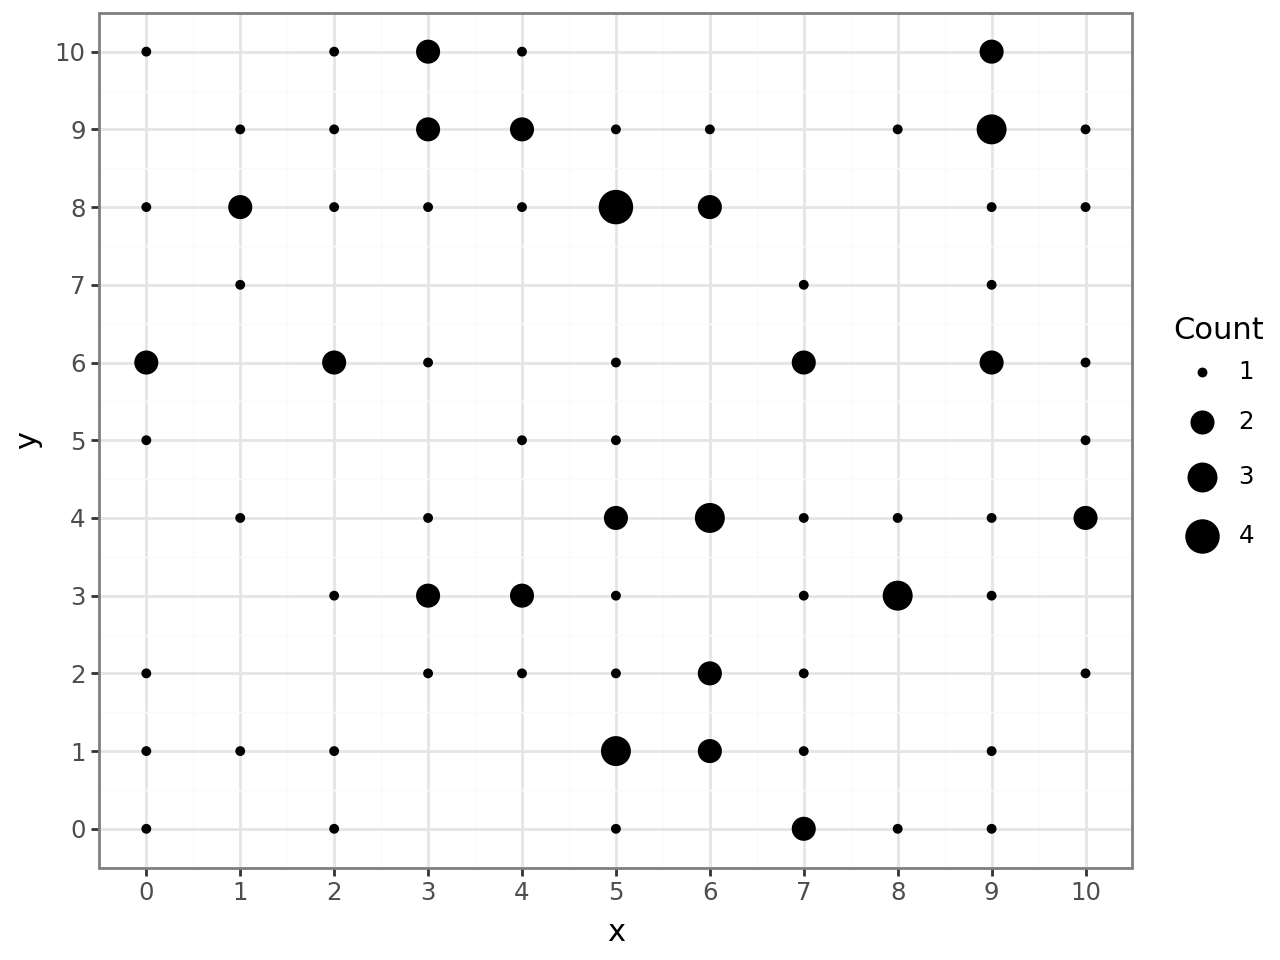

In [7]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_sum(
        mapping=p9.aes(
            x="x",
            y="y",
        )
    )
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.scale_size_continuous(name="Count")  # Give size legend a  name
    + p9.theme_bw()
)
plot

The plot above is a better visualization, but I wanted the different counts to stand out more.

The code below assigns a unique color to the different count values (held in a pseudo-variable "n", created by the __stat_sum__ process, before it calls __geom_point__). 

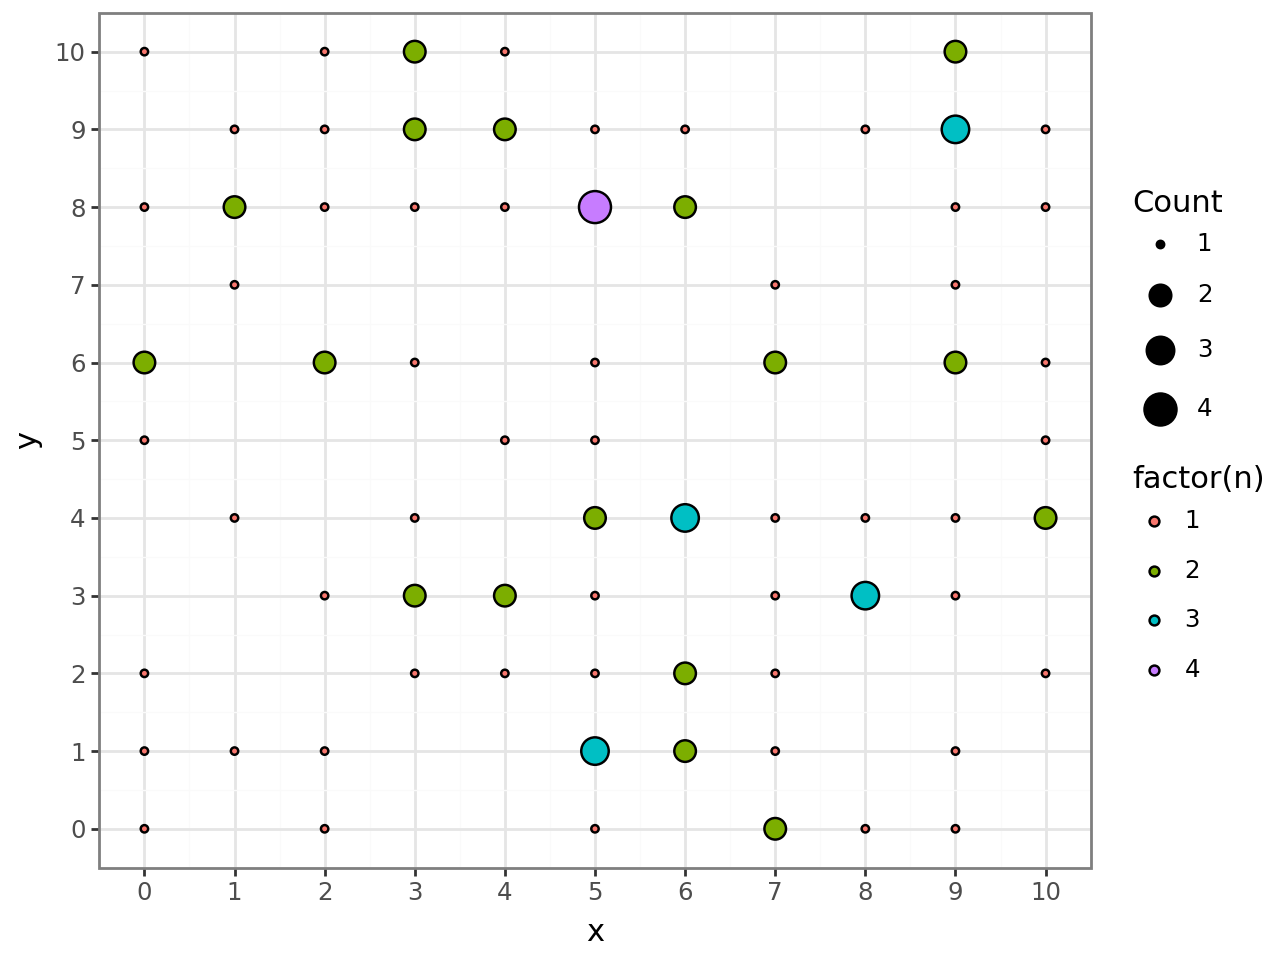

In [8]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_sum(mapping=p9.aes(x="x", y="y", fill=p9.after_stat("factor(n)")))
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.scale_size_continuous(name="Count")  # Give size legend a meaningful name
    + p9.theme_bw()
)
plot

The extra legend in the plot above is annoying, but we can fix that by telling __plotnine__ we want the fill and size legends be be combined under the name "Count".

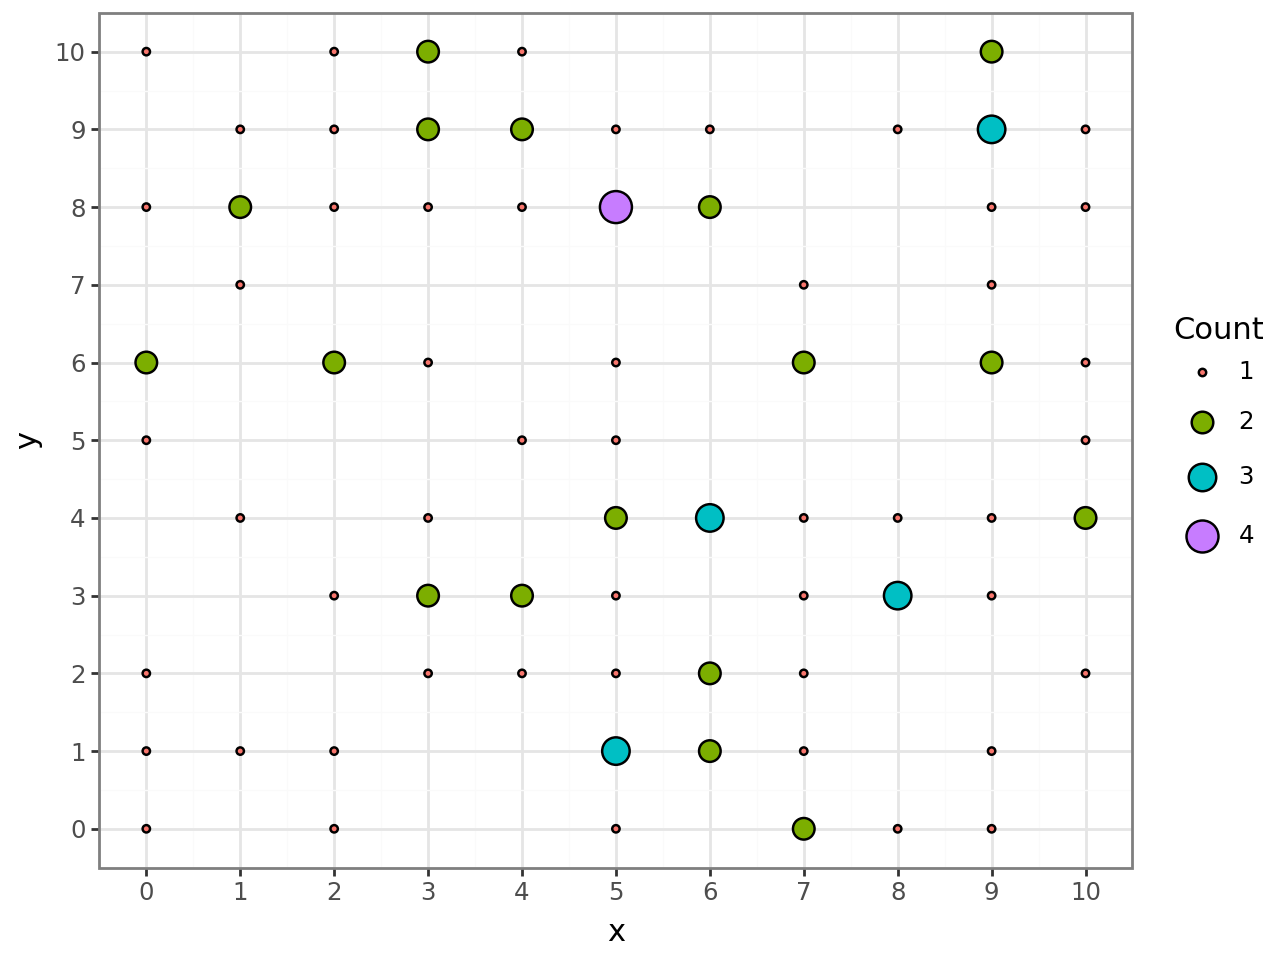

In [9]:
plot = (
    p9.ggplot(data=df)
    + p9.stat_sum(mapping=p9.aes(x="x", y="y", fill=p9.after_stat("factor(n)")))
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.scale_size_continuous(name="Count")  # Give size legend a meaningful name
    + p9.scale_fill_discrete(name="Count")  # Give color legend the same name
    + p9.theme_bw()
)
plot

--------------------------------

## stat_summary

As an introduction to __stat_summary__, I explore the __geom__ that it calls by default (__geom_point_range__)

### goem_pointrange

This __geom__ draws a vertical line (ranging from the maximum and minimum y values supplied), and draws a point at the y value supplied).

The default plot looks like that below: I create 10 vertical lines.  Note there is no constraint that forces the "central" point (the y value supplied) to be between ymin and ymax.

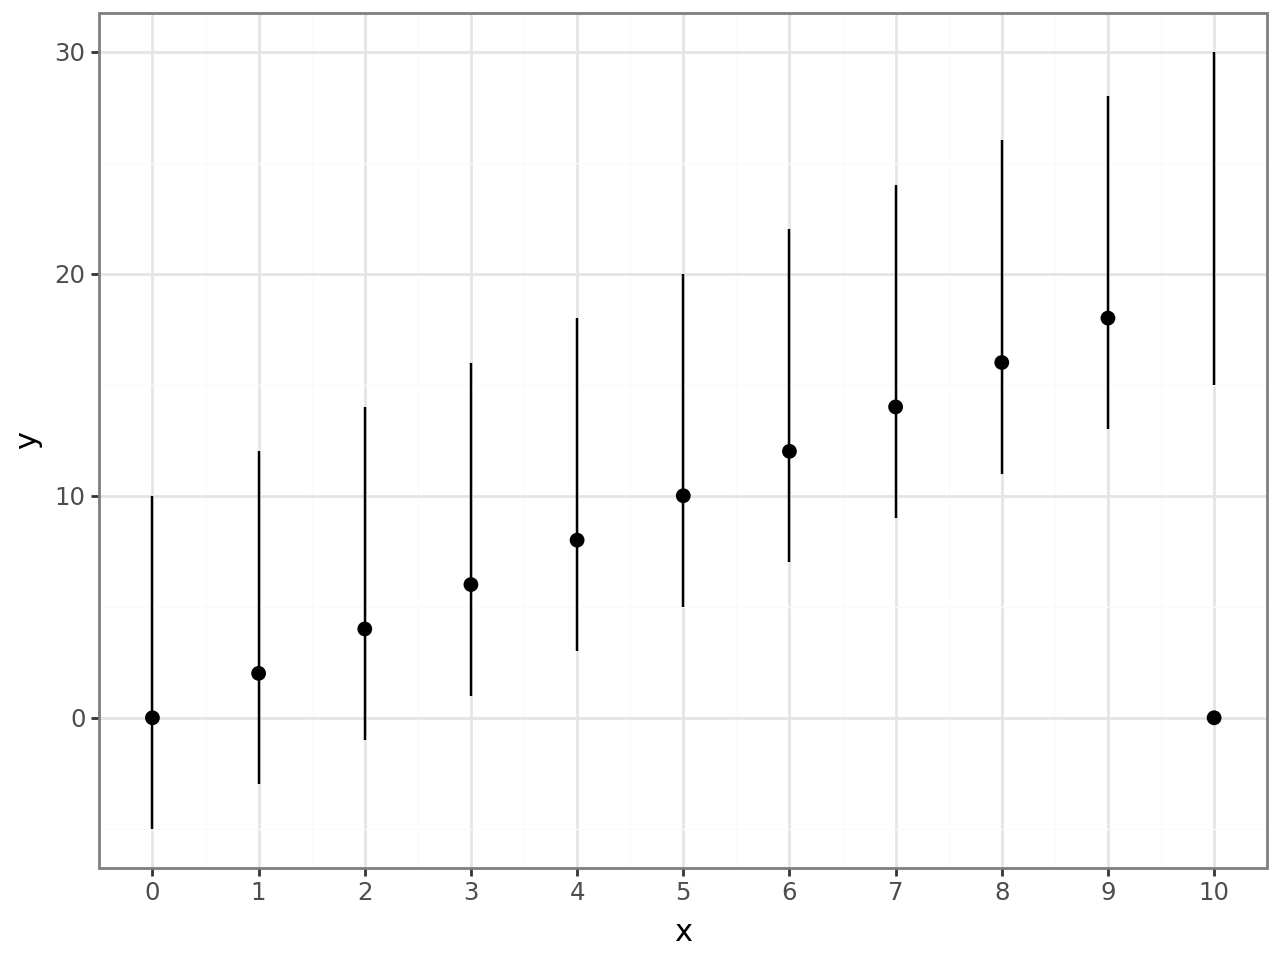

In [10]:
# create illustrative data
x = [i for i in range(11)]
y = [v * 2 for v in x]
ymax = [v + 10 for v in y]
ymin = [v - 5 for v in y]
y[-1] = 0 # create a "central" point below ymin

df = pd.DataFrame({"x": x, "y": y, "ymax": ymax, "ymin": ymin})

# generate plot
plot = (
    p9.ggplot(data=df)
    + p9.geom_pointrange(
        mapping=p9.aes(x="x", y="y", ymin="ymin", ymax="ymax"),
    )
    # set x axis tick marks
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)
plot

Just for completness, we show that indeed the vertical lines that __geom_pointrange__ start and end at ymin, ymax respectively.  We draw points at the ymin and ymax positions and they coincide with the end if the vertical line.

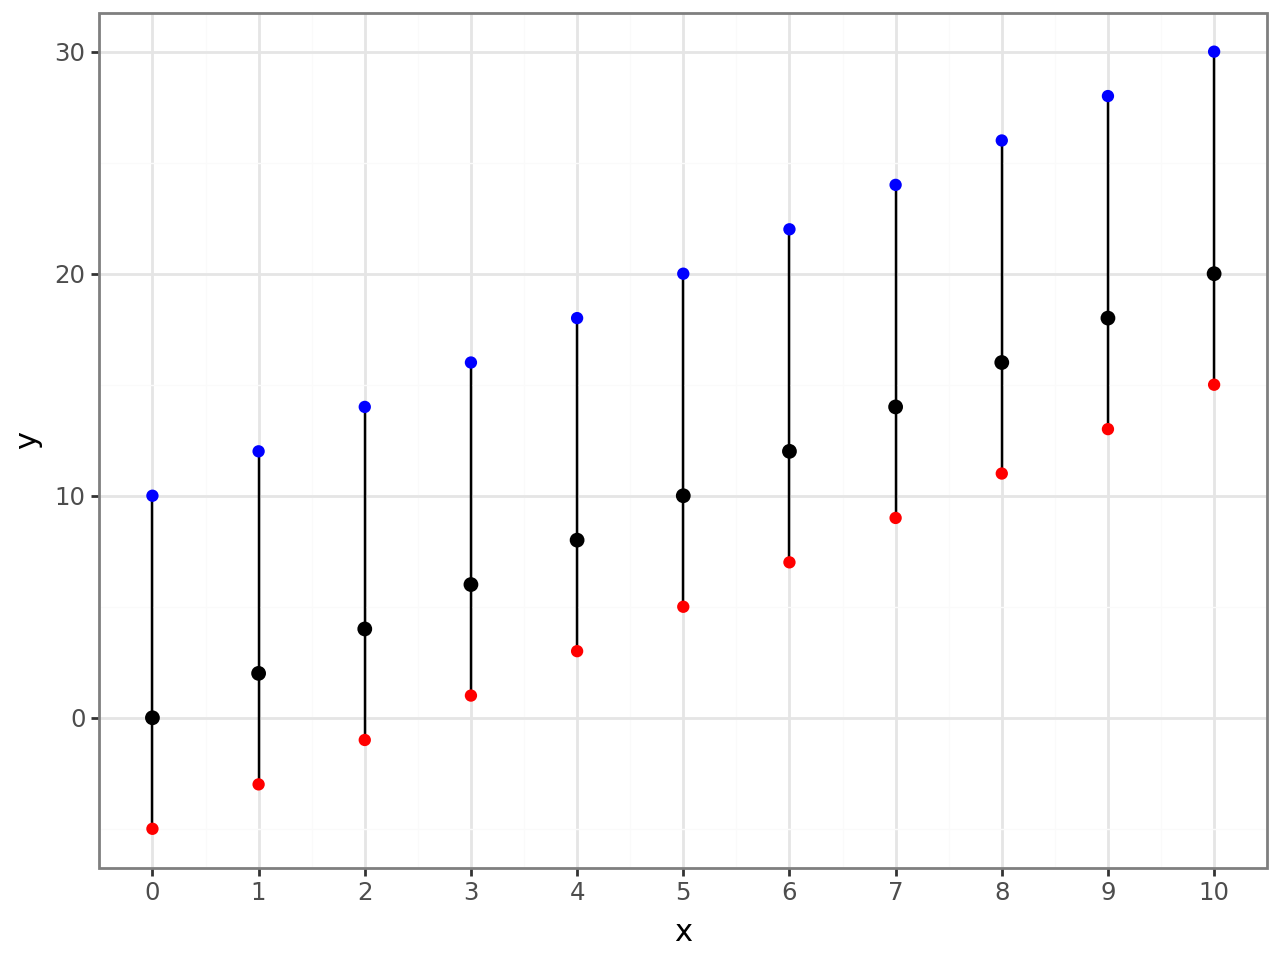

In [11]:
x = [i for i in range(11)]
y = [v * 2 for v in x]
ymax = [v + 10 for v in y]
ymin = [v - 5 for v in y]

df = pd.DataFrame({"x": x, "y": y, "ymax": ymax, "ymin": ymin})

plot = (
    p9.ggplot(data=df)
    + p9.geom_pointrange(
        mapping=p9.aes(x="x", y="y", ymin="ymin", ymax="ymax"),
    )
    # draw upper points
    + p9.geom_point(mapping=p9.aes(x="x", y="ymin"), color="red")
    # draw lower points
    + p9.geom_point(mapping=p9.aes(x="x", y="ymax"), color="blue")
    # set x axis tick marks
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)
plot

-----------------------

## stat_summary a la boxplot

The data proccesing performed by __stat_summary__ is determined by the _fun_data_ parameter.  In the example below, we generate normally distributed y values at a number of x xoordinate values (0-10).  If we ask for "median_hilow" processing: the resulting graph (I believe) shows a graphical result similar to a box plot

Generate example data: 20 normally distributed y values for each x coordinate value

In [12]:
xx = []
yy = []
av = []

for x in range(1, 11):
    jj = np.random.normal(x * 2, 5, 20)
    for j in jj:
        xx.append(x)
        yy.append(j)
        av.append(np.median(jj))
    # end for
# end for

Visualize the data summary  (for context, we add the original data points, and the median y value for each x coordinate).  The point on the line is the median value (confirmed by computing the median with numpy, and plotting a cross, that overlays the point).  I think the lines extend as per the box plot: see below for a description of the boxplot visualization

    The lower bottom and upper top of the boxes correspond to the first and third quartiles (the 25th and 75th percentiles). 

    The upper whisker extends from the box top to the largest value no further than 1.5 * IQR from the hinge (where IQR is the inter-quartile range, or distance between the first and third quartiles). The lower whisker extends from the box bottom to the smallest value at most 1.5 * IQR of the hinge. Data beyond the end of the whiskers are called "outlying" points and are plotted individually.



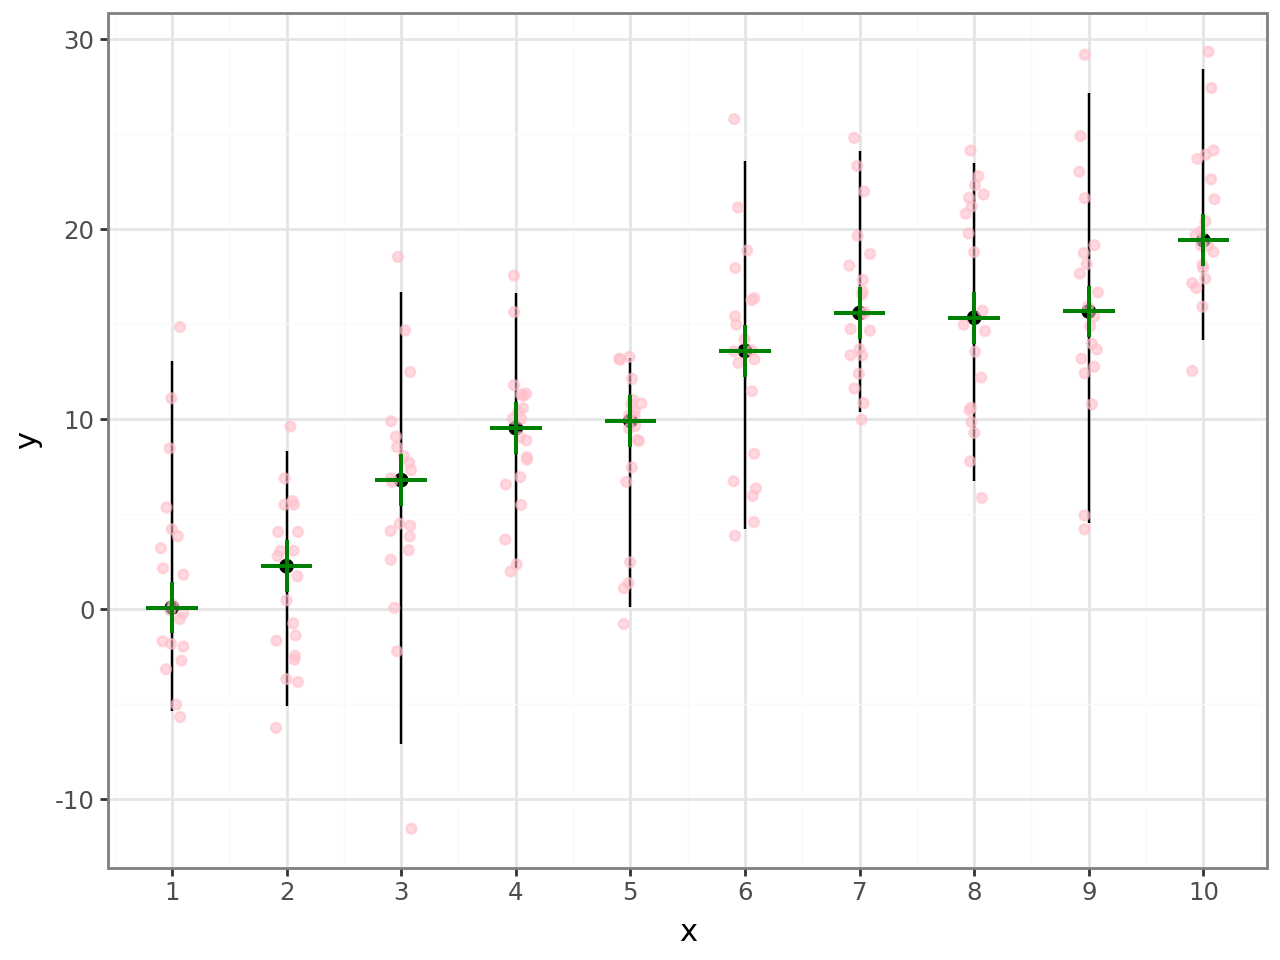

In [13]:
df = pd.DataFrame({"x": xx, "y": yy, "av": av})

plot = (
    p9.ggplot(data=df)
    + p9.stat_summary(
        mapping=p9.aes(
            x="x",
            y="y",
        ),
        fun_data="median_hilow",
    )
    # add additional items for context: original y values, computed median y value
    + p9.geom_jitter(mapping=p9.aes(x="x", y="y"), color="pink", alpha=0.6, width=0.1)
    + p9.geom_point(mapping=p9.aes(x="x", y="av"), color="green", shape="+", size=10)
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)
plot

------------------

## Confidence limits

We can also ask the vertical line to represent a confidence limit on the estimate of the mean of the data points at each X coordinate (assuming normal distribution of y values).

In the example below, we show the original data points, the estimated true mean, and the confidence limit on the estimated mean (the true mean will fall above or below the vertical blue line only 5% of the time)  

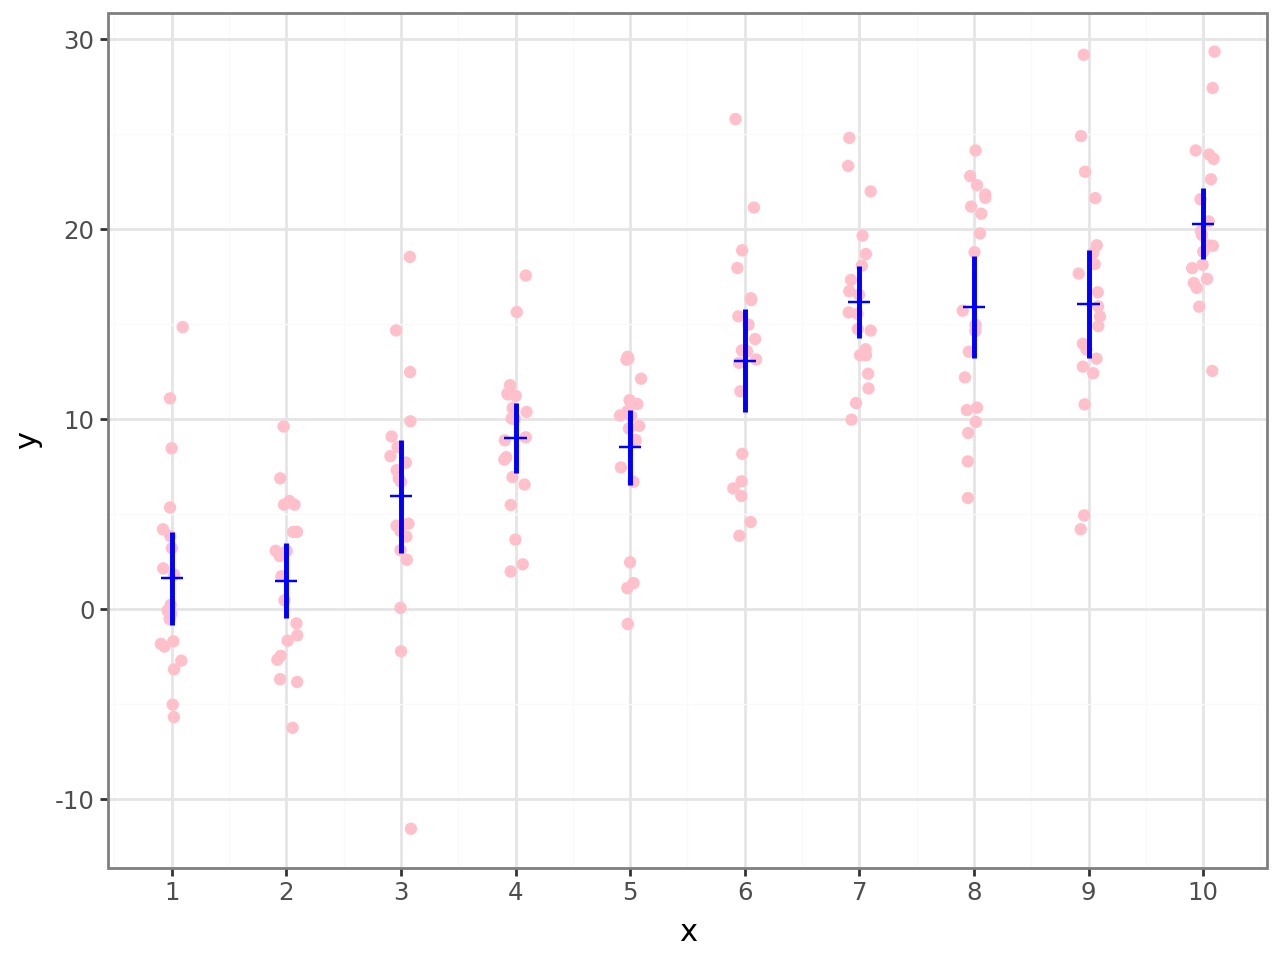

In [14]:
plot = (
    p9.ggplot(data=df)
    # show original data points
    + p9.geom_jitter(mapping=p9.aes(x="x", y="y"), color="pink", alpha=1, width=0.1)
    # summarise original data points
    + p9.stat_summary(
        mapping=p9.aes(
            x="x",
            y="y",
        ),
        fun_data="mean_cl_normal",
        fun_args={"confidence_interval": 0.95},
        size=1,
        shape="+",
        color="blue",
    )
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)
plot

In the example below, we ask for a confidence limit that will be wrong only 1 times in a 1000.  Accordingly, each confidence limit (vertical line) spans is longer

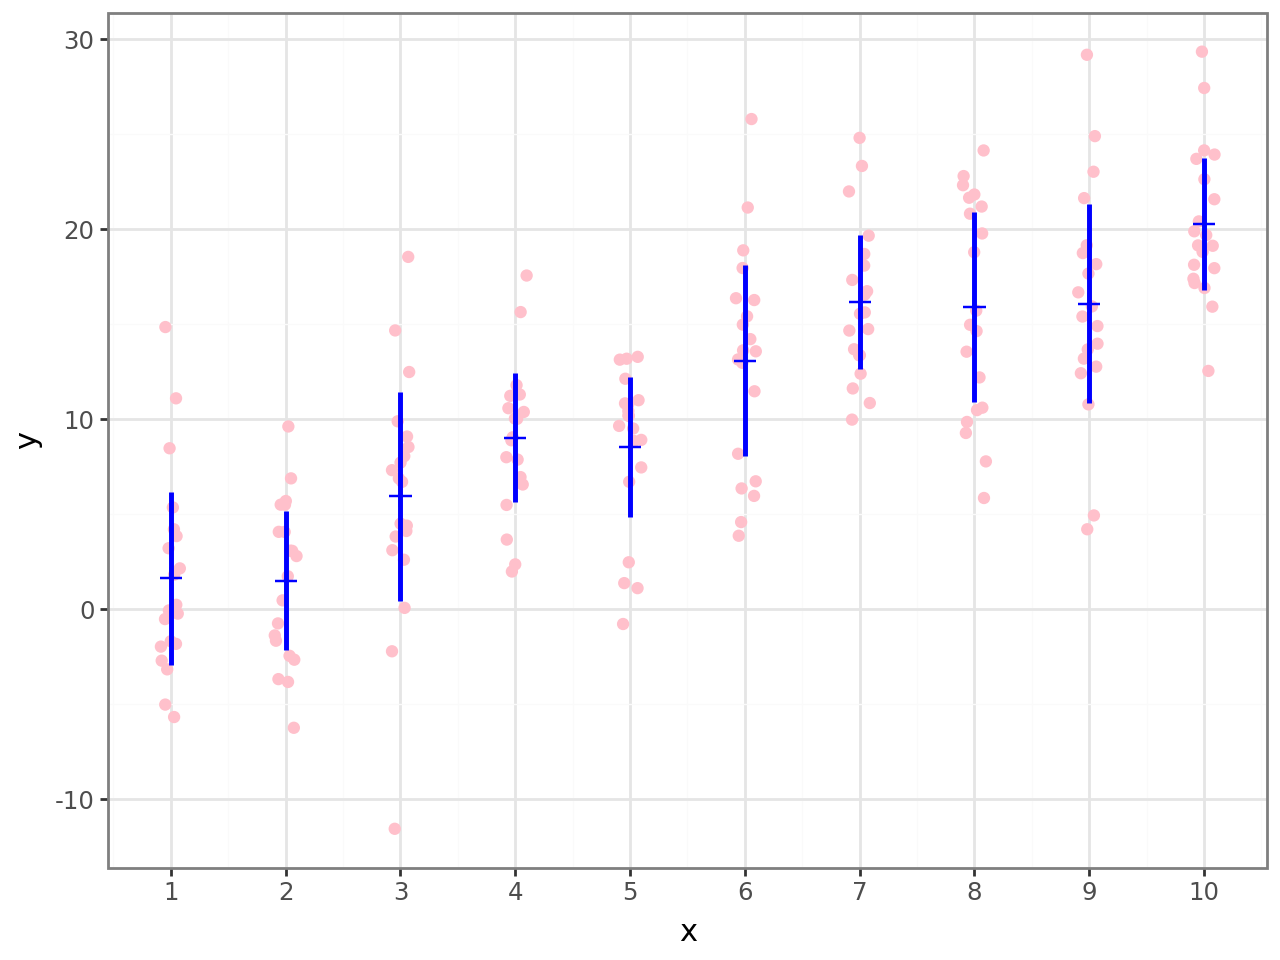

In [15]:
plot = (
    p9.ggplot(data=df)
    # show original data points
    + p9.geom_jitter(mapping=p9.aes(x="x", y="y"), color="pink", alpha=1, width=0.1)
    # show graphical summary of y data value at each x coordinate
    + p9.stat_summary(
        mapping=p9.aes(
            x="x",
            y="y",
        ),
        fun_data="mean_cl_normal",
        fun_args={"confidence_interval": 0.999},
        size=1,
        shape="+",
        color="blue",
    )
    # st tick marks on x axis
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.theme_bw()
)
plot

---------------------------

## Drawing circles: a diversion

I went down a rabbit hole, when I asked: how do I draw a circle in __plotnine__.

Not easily, but possible.  One varient of __stat_ellipse__ (described previously) can be used to draw a circle, where the center of the circle is the center of the point cloud being summarised. So if you create a point cloud (4 is enough) that has a centre at your desired point, you can call __stat_ellipse__ to draw a circle.

In [16]:
def add_circle(
    plot,
    x0: float,
    y0: float,
    radius: float,
    alpha: float = 1.0,
    linetype: str = "solid",
):
    """
    add_circle: adds a circle to plotnine plot, center at point x0,y0, radius=radius

    Parameters
    plot: a plotnine ggplot

    x0: x-axis coordinate of circle center
    y0: y-axis coordinate of circle center
    radius: radius of circle
    alpha: transparency value - defaults to no transparency
    linetype: plotnine line type, defaults to solid line

    Returns:
    Updated ggplot object

    Design:
    create a dataframe holding the coordinates of a box around the center X,Y value,
    and add to the input plot the results of a call to stat_ellipse, with the ellipse type set to euclid

    """

    x = [x0 - 1, x0 - 1, x0 + 1, x0 + 1]
    y = [y0 - 1, y0 + 1, y0 + 1, y0 - 1]

    df2 = pd.DataFrame({"x": x, "y": y})

    plot = plot + (
        p9.stat_ellipse(
            data=df2,
            mapping=p9.aes(x="x", y="y"),
            level=radius,
            type="euclid",
            alpha=alpha,
            linetype=linetype,
        )
    )

    return plot


# end add_circle

We use the helper function above, to draw a circle around every X,Y coordinate pair where we have data points.  
The jitter value is chosen to have points lie inside the circle of radius 0.5

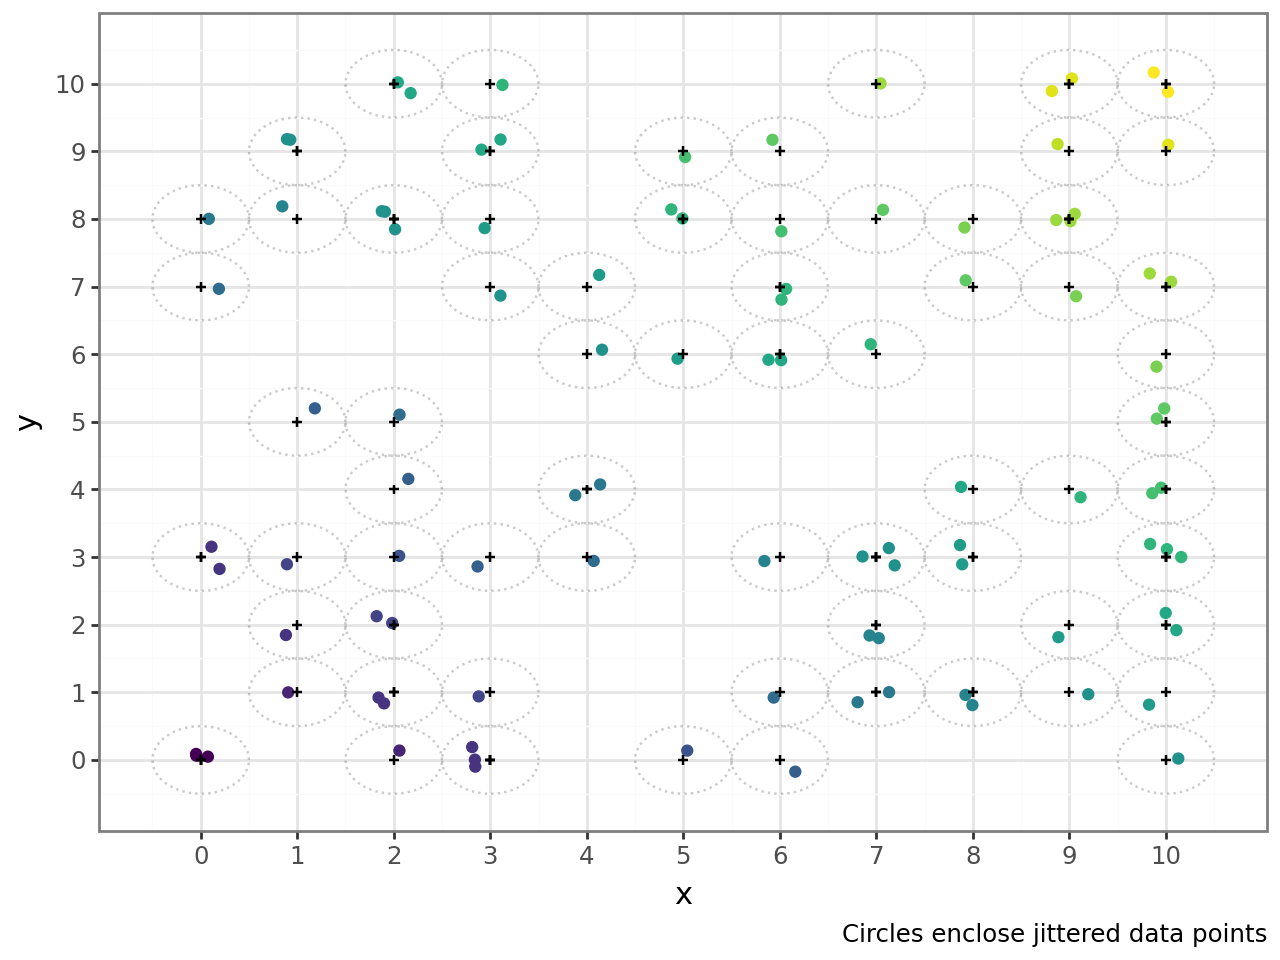

In [17]:
# create example data

x = np.random.randint(low=0, high=11, size=100)
y = np.random.randint(low=0, high=11, size=100)
df = pd.DataFrame({"x": x, "y": y})

# parameters of the visualization
jitter = 0.2
circle_radius = 0.5

plot = (
    p9.ggplot(data=df)
    # plot jittered points
    + p9.geom_jitter(
        mapping=p9.aes(x="x", y="y", color="x+y"),
        width=jitter,
        height=jitter,
        show_legend=False,
    )
    # plot (and overplot) centers of each jittered point cloud as a +
    + p9.geom_point(
        mapping=p9.aes(
            x=x,
            y=y,
        ),
        shape="+",
        show_legend=False,
    )
    # set x and y axis tick marks
    + p9.scale_x_continuous(breaks=list(range(0, 11)))
    + p9.scale_y_continuous(breaks=list(range(0, 11)))
    # go for balk and white theme
    + p9.theme_bw()
)

# loop adding circles to plot
for xx in range(0, 11):
    for yy in range(0, 11):
        # only draw a circle if there are data points at this X,Y coordinate
        if (xx, yy) in zip(df["x"], df["y"]):
            # add dotted very transparent circle at this X,Y coordinate
            plot = add_circle(plot, xx, yy, circle_radius, alpha=0.2, linetype="dotted")
        # end if
    # end for
# end for

plot + p9.labs(caption="Circles enclose jittered data points")

## End of diversion

---------------------------

## Using __stat_boxplot__

The __stat_boxplot__ process creates the following pseudo-variables (amongst others):


- "lower"  =  25% quantile
- "middle" = median, 50% quantile
- "upper"  #=-  75% quantile

- "ymin" = smallest observation greater than or equal to lower hinge - 1.5 * IQR


- "ymax" = largest observation less than or equal to upper hinge + 1.5 * IQR

where IQR is the inter-quartile range, or distance between the first and third quartiles

We can use these pseudo-variables in whatever geom we specify to be called after the __stat_boxplot__ has finsihed processing the input data.

Some observations:  

- __stats_boxplot__ seems to create a pseudo_variable in the after-processing environment "group", which can cause problems with some of the __geom__ visualization tools we might want to call.  We can fix this by declaring that the after_stat value is 0 in the __mapping=p9.aes(...)__ call (i.e. a constant for all data points)
- __stats_boxplot__ requires discrete x values: we fix this by declaring that we want processing to occur treating "x" as a "factor" (i.e. discrete, not continuous)
- __geom_path__, __geom_point__  expect a pseudo-variable "y": we use the plotnine __stage__ function to specify where to get "y" values at the data processing stage (start= ...) and in the visualization stage (after=...)
- some of the visual artefacts we create we want to have a constant color (i.e. the same for all points or line segments).  If we double wrap a color name (e.g. "'red'", plotnine will treat it as a constant, and not a dataframe column pseudo-variable.  These color assignments must be in the __mapping=p9.aes(...)__ call, in order for the colors to appear in the legend,
  


Create example data: normally distributed values at x value 0-10.

In [18]:
xx = []
yy = []
av = []

for x in range(1, 11):
    jj = np.random.normal(x * 2, 5, 20)
    for j in jj:
        xx.append(x)
        yy.append(j)
        av.append(np.median(jj))
    # end for
# end for

Draw curves for the following pseudo-variables after __stat_boxplot__ operates on our data:
- "lower" 
- "middle"
- "upper" 
- "ymin" 
- "ymax" 

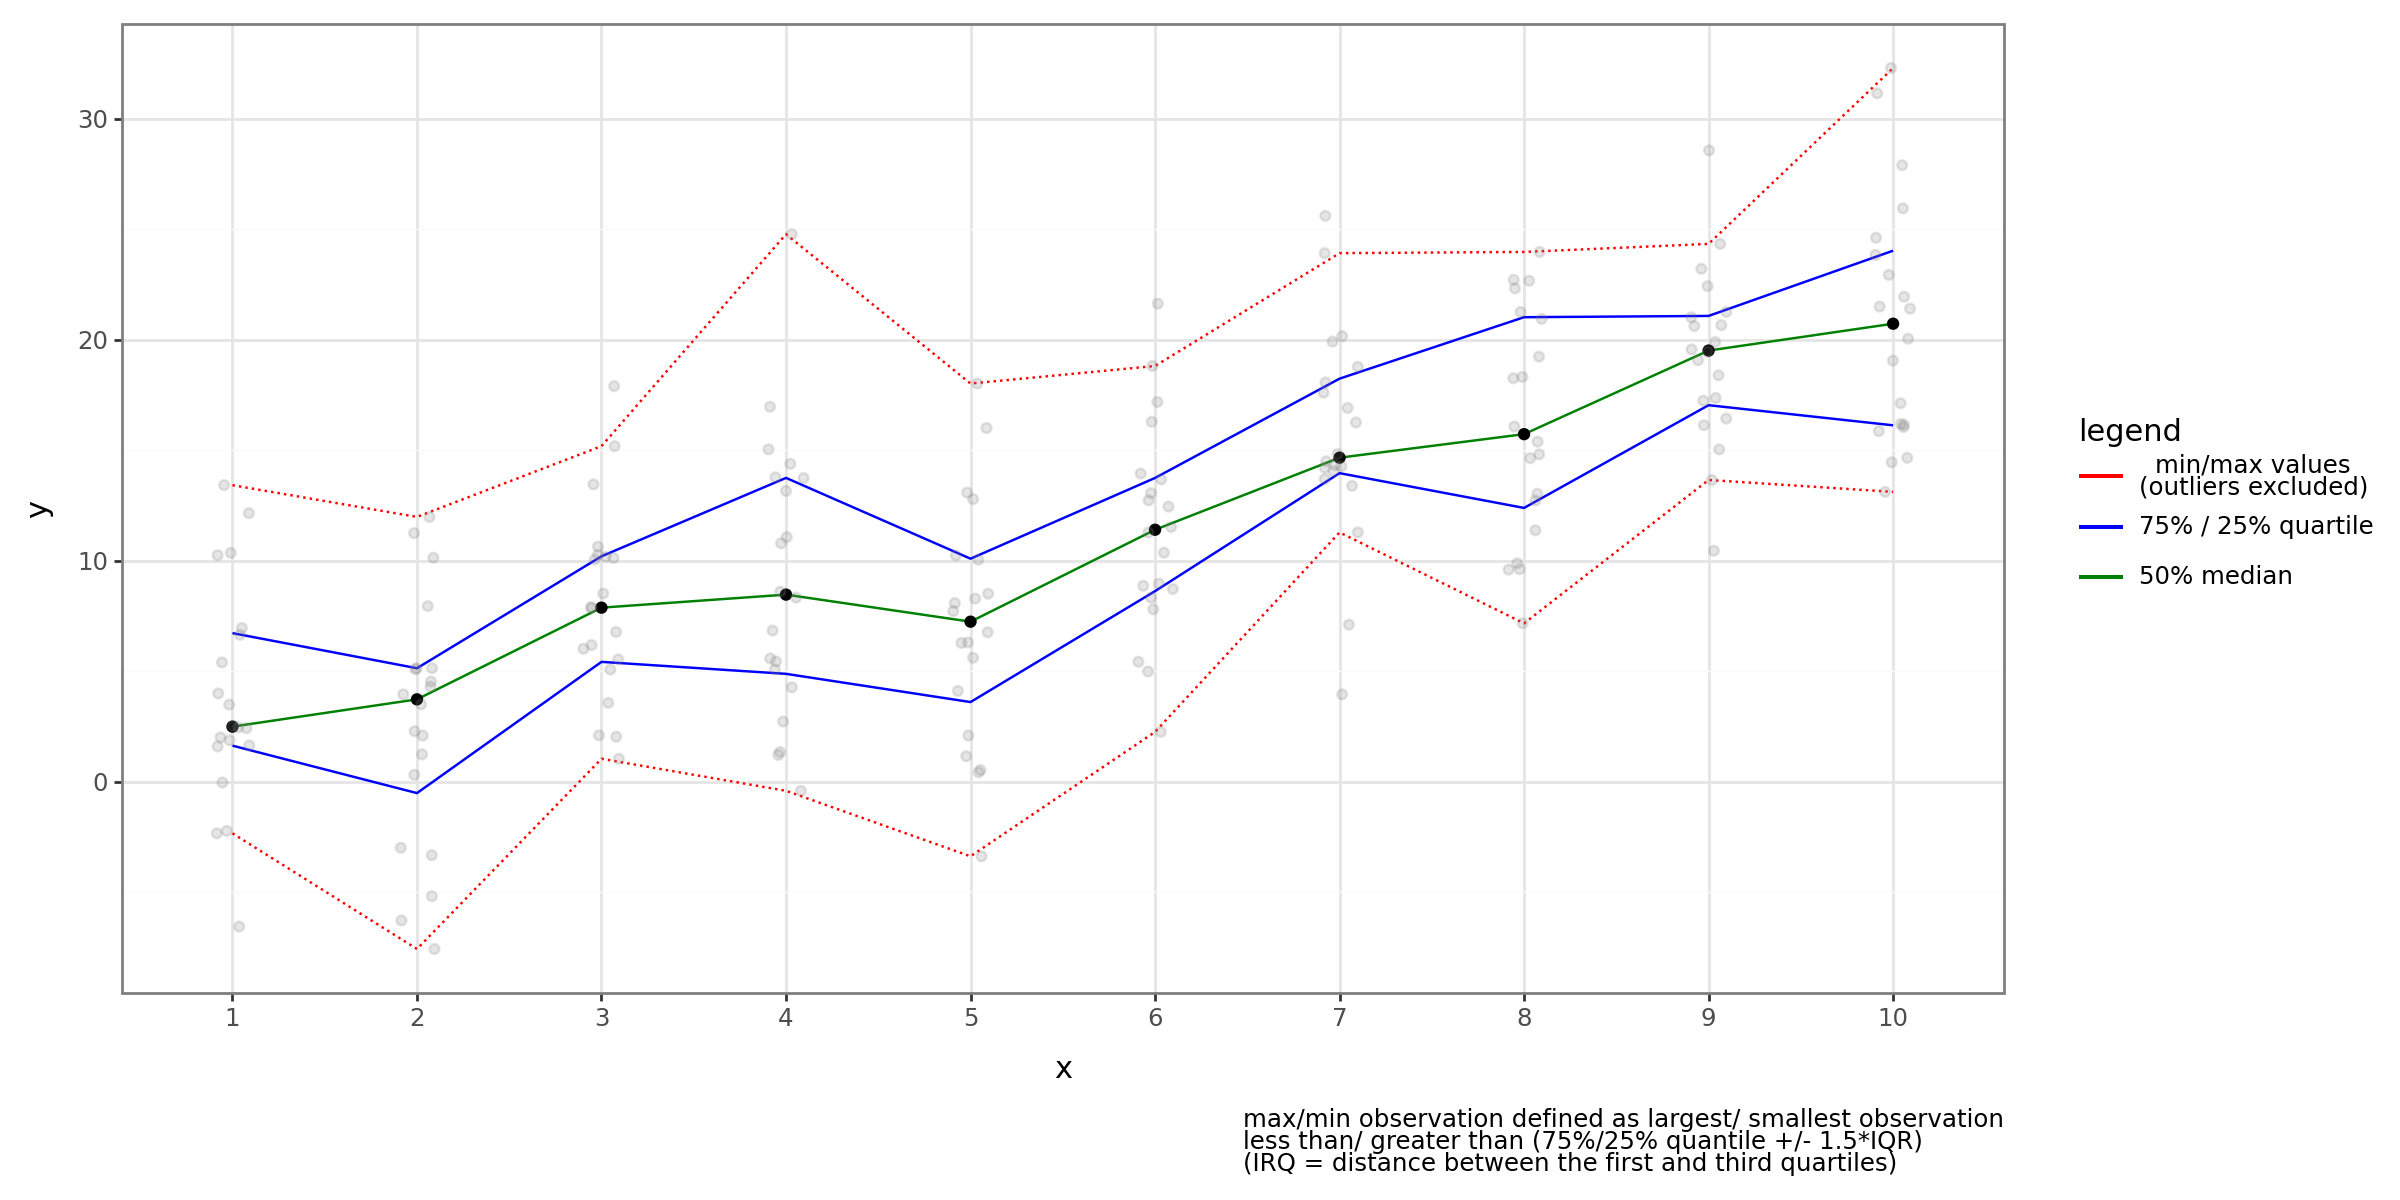

In [19]:
df = pd.DataFrame({"x": xx, "y": yy, "av": av})
xxx = list(range(1, 11))

caption = (
    "max/min observation defined as largest/ smallest observation\n"
    + "less than/ greater than (75%/25% quantile +/- 1.5*IQR)\n"
    + "(IRQ = distance between the first and third quartiles)"
)


plot = (
    # create empty plot
    p9.ggplot(data=df)
    # draw minimum y value (outliers excluded) curve, in red
    + p9.stat_boxplot(
        mapping=p9.aes(
            x="factor(x)",
            y=p9.stage(start="y", after_stat="ymin"),
            color=p9.after_stat('"red"'),
            group=p9.after_stat(0),
        ),
        geom="path",
        linetype="dotted",
        show_legend=True,
    )
    # draw maximum y value (outliers excluded) curve, in red
    + p9.stat_boxplot(
        mapping=p9.aes(
            x="factor(x)",
            y=p9.stage(start="y", after_stat="ymax"),
            group=p9.after_stat(0),
        ),
        geom="path",
        color="red",
        linetype="dotted",
        show_legend=True,
    )
    # draw 25% quartile y value  curve, in blue
    + p9.stat_boxplot(
        mapping=p9.aes(
            x="factor(x)",
            y=p9.stage(start="y", after_stat="lower"),
            group=p9.after_stat(0),
        ),
        geom="path",
        color="blue",
        show_legend=True,
    )
    # draw 75% quartile y value  curve, in blue
    + p9.stat_boxplot(
        mapping=p9.aes(
            x="factor(x)",
            y=p9.stage(start="y", after_stat="upper"),
            group=p9.after_stat(0),
            color=p9.after_stat("'blue'"),
        ),
        geom="path",
        show_legend=True,
    )
    # draw 50% quartile y value  curve (median)
    + p9.stat_boxplot(
        mapping=p9.aes(
            x="factor(x)",
            y=p9.stage(start="y", after_stat="middle"),
            group=p9.after_stat(0),
            color=p9.after_stat("'green'"),
        ),
        geom="path",
        show_legend=True,
    )
    # draw 50% quartile y value (outliers excluded) points
    + p9.stat_boxplot(
        mapping=p9.aes(x="factor(x)", y=p9.stage(start="y", after_stat="middle")),
        geom="point",
    )
    # add additional items for context: original y values
    + p9.geom_jitter(
        mapping=p9.aes(x="factor(x)", y="y"), color="gray", alpha=0.2, width=0.1
    )
    + p9.theme_bw()
    # create labels for our color legend
    + p9.scale_color_identity(
        name="legend",
        guide="legend",
        breaks=["red", "blue", "green"],
        labels=[
            "min/max values\n(outliers excluded)",
            "75% / 25% quartile",
            "50% median",
        ],
    )
    # set labels
    + p9.labs(x="x", y="y", caption=caption)
    # set legend position and plot size
    + p9.theme(
        legend_position="right",
        figure_size=(12, 6),
    )
)
plot

To my mind the plot above is prefereable to a boxplot style graphic!


---------------------

## Conclusions

I think that __stat_sum__ is more likely to be used.  However it is worth understanding the operations each __stat__  performs, as they might be able to be used productively with a non-default __geom__

--------------------

## Reproducability


In [20]:
%watermark

Last updated: 2026-02-26T15:10:40.815964+10:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 9.10.0

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [21]:
%watermark -h -iv -co

conda environment: fun_minim

Hostname: INSPIRON16

numpy   : 2.4.1
pandas  : 2.3.3
plotnine: 0.15.0
scipy   : 1.16.3



In [22]:
import contextlib

import ipynbname

with contextlib.suppress(FileNotFoundError):
    print(f"Notebook file name: {ipynbname.name()}")
# end with

Notebook file name: stat_sum
